<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/AML_clinical_patient_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===========================================
# Exploratory Data Analysis (EDA)
# AML Clinical Patient Dataset (Training Set)
# ===========================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

# ------------------------------------------
# Load training dataset
# ------------------------------------------

DATA_PATH = "/content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/Clinical Patient/split_and_imputed/train_imputed.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(620, 22)


,PATIENT_ID,PROTOCOL,SEX,RACE,ETHNICITY,AGE_IN_DAYS,AGE,WBC,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,PERIPHERAL_BLASTS_PERCENTAGE,...,FAB,CYTOGENETIC_COMPLEXITY,PRIMARY_CYTOGENETIC_CODE,RISK_GROUP,DAYS_TO_EVENT,FIRST_EVENT,OS_STATUS,OS_DAYS,OS_MONTHS,OS_EVENT
0,TARGET-20-PARNIL,AAML0531,Male,White,Hispanic or Latino,5405.0,15.0,207.2,70.0,18.0,...,M4,1,inv(16),Low,1.0,Death without remission,1:DECEASED,1.0,1.0,1.0
1,TARGET-20-PAPZYS,AAML0531,Male,White,Hispanic or Latino,2357.0,7.0,1.7,90.0,0.0,...,M1,0,Normal,Standard,522.0,Relapse,0:LIVING,2566.0,85.0,0.0
2,TARGET-20-PASKUA,AAML0531,Male,Black or African American,Not Hispanic or Latino,3682.0,11.0,76.4,69.2,66.0,...,M2,0,Normal,High,190.0,Relapse,1:DECEASED,721.0,24.0,1.0
3,TARGET-20-PARMME,AAML0531,Female,White,Not Hispanic or Latino,3832.0,11.0,17.5,90.0,61.0,...,M1,0,Normal,High,2363.0,Censored,0:LIVING,2363.0,78.0,0.0
4,TARGET-20-PARTYV,AAML0531,Male,White,Hispanic or Latino,1636.0,5.0,93.9,80.0,64.0,...,M1,0,Normal,High,406.0,Censored,0:LIVING,406.0,14.0,0.0


In [ ]:
print("="*50)
print("Dataset Overview")
print("="*50)

print("Number of patients:", len(df))
print("Number of variables:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

Dataset Overview
Number of patients: 620
Number of variables: 22

Column names:
['PATIENT_ID', 'PROTOCOL', 'SEX', 'RACE', 'ETHNICITY', 'AGE_IN_DAYS', 'AGE', 'WBC', 'BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE', 'PERIPHERAL_BLASTS_PERCENTAGE', 'CNS_DISEASE', 'CHLOROMA', 'FAB', 'CYTOGENETIC_COMPLEXITY', 'PRIMARY_CYTOGENETIC_CODE', 'RISK_GROUP', 'DAYS_TO_EVENT', 'FIRST_EVENT', 'OS_STATUS', 'OS_DAYS', 'OS_MONTHS', 'OS_EVENT']


In [ ]:
print("="*50)
print("Variable Types")
print("="*50)

print(df.dtypes)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(include="object").columns.tolist()

print("\nNumerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)

Variable Types
PATIENT_ID                                object
PROTOCOL                                  object
SEX                                       object
RACE                                      object
ETHNICITY                                 object
AGE_IN_DAYS                              float64
AGE                                      float64
WBC                                      float64
BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE    float64
PERIPHERAL_BLASTS_PERCENTAGE             float64
CNS_DISEASE                               object
CHLOROMA                                  object
FAB                                       object
CYTOGENETIC_COMPLEXITY                    object
PRIMARY_CYTOGENETIC_CODE                  object
RISK_GROUP                                object
DAYS_TO_EVENT                            float64
FIRST_EVENT                               object
OS_STATUS                                 object
OS_DAYS                                  float64
OS_MO

In [ ]:
print("="*50)
print("Remaining Missing Values")
print("="*50)

missing = df.isna().sum()

print(missing[missing > 0])

print("\nTotal missing values:",
      missing.sum())

Remaining Missing Values
RISK_GROUP    23
dtype: int64

Total missing values: 23


In [ ]:
print("="*50)
print("Summary Statistics")
print("="*50)

display(df[numeric_cols].describe())

Summary Statistics


,AGE_IN_DAYS,AGE,WBC,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,PERIPHERAL_BLASTS_PERCENTAGE,DAYS_TO_EVENT,OS_DAYS,OS_MONTHS,OS_EVENT
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000
mean,3456.450000,9.975806,69.141452,65.094368,46.127618,1125.020968,1497.995161,49.756452,0.359677
std,2283.594714,6.242364,91.196071,24.320293,31.900757,962.387717,918.788253,30.217099,0.480293
min,8.000000,1.000000,0.200000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,1118.000000,4.000000,11.200000,48.000000,16.000000,258.500000,550.750000,18.750000,0.000000
50%,3711.000000,11.000000,30.000000,71.000000,47.750000,724.500000,1675.000000,56.000000,0.000000
75%,5410.000000,15.000000,86.800000,85.633500,75.000000,1990.250000,2206.250000,73.000000,1.000000
max,10898.000000,30.000000,610.000000,100.000000,99.000000,4037.000000,4127.000000,136.000000,1.000000


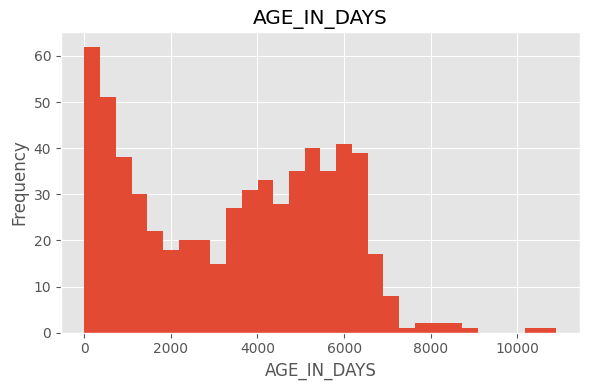

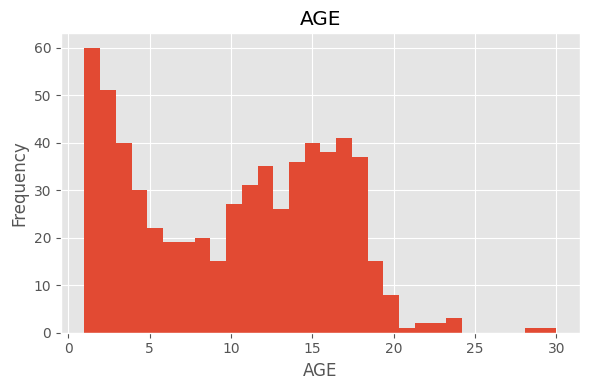

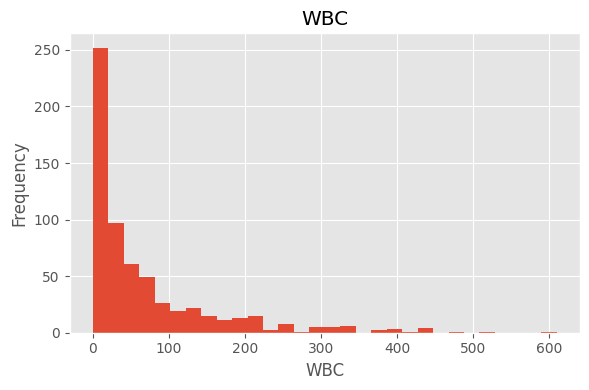

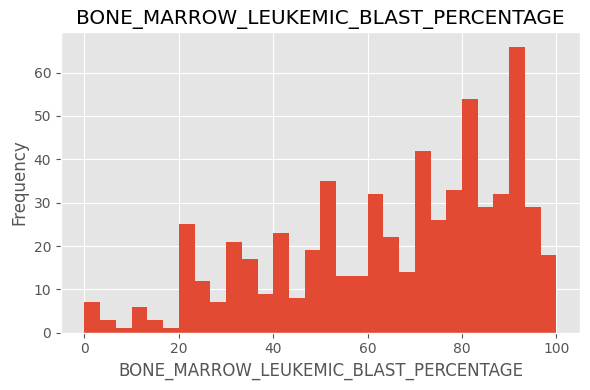

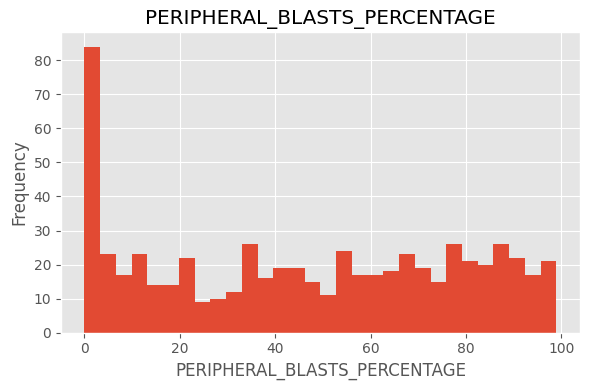

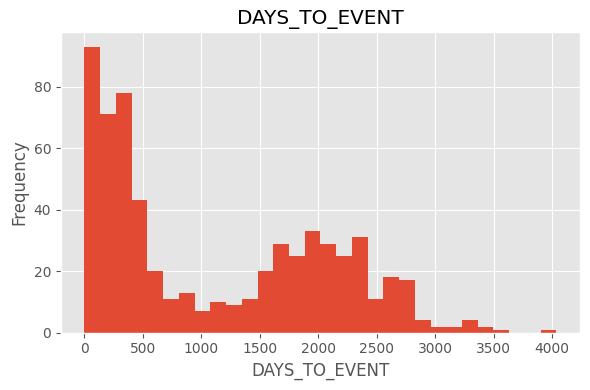

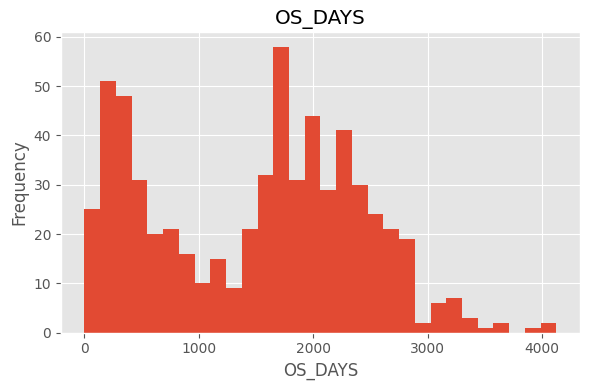

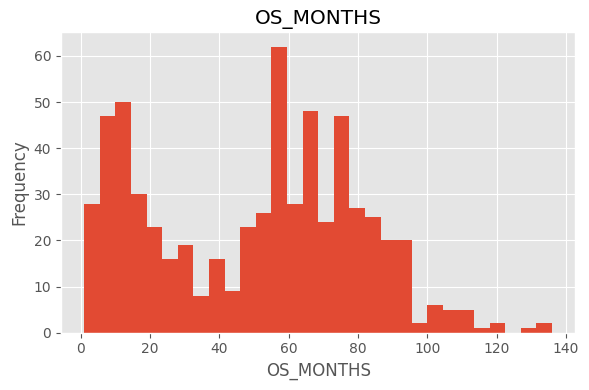

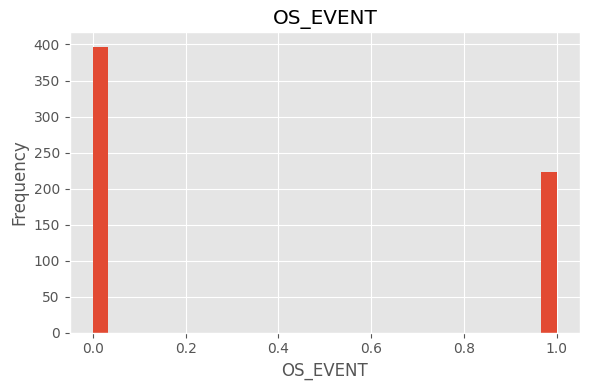

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    plt.hist(df[col], bins=30)

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

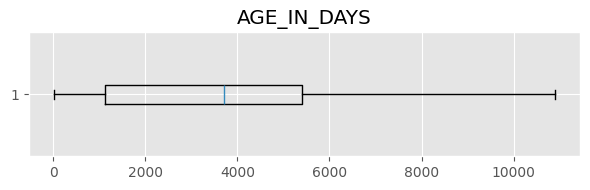

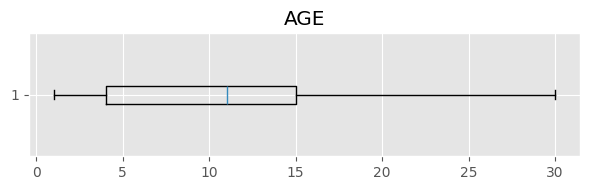

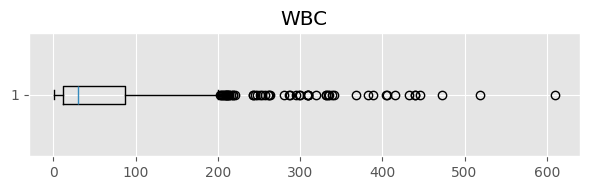

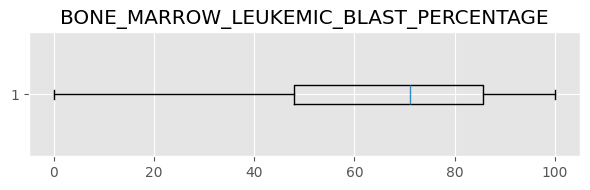

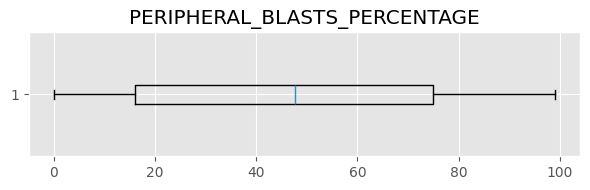

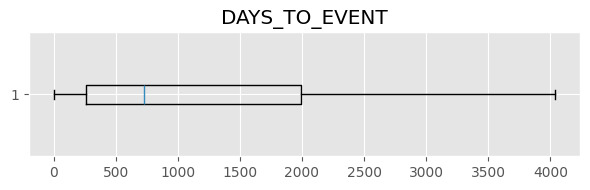

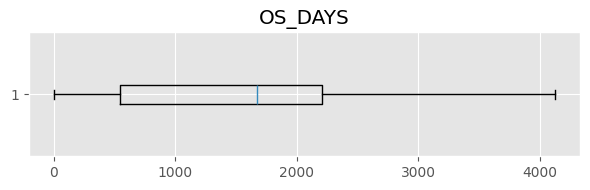

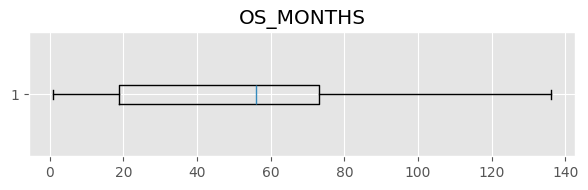

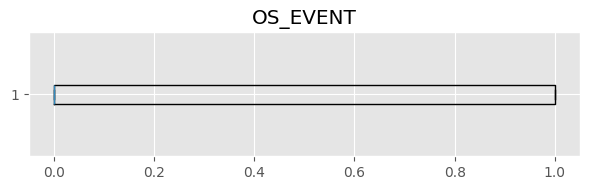

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,2))

    plt.boxplot(df[col],
                vert=False)

    plt.title(col)

    plt.tight_layout()

    plt.show()

PATIENT_ID


,count
PATIENT_ID,
TARGET-20-PARKFB,1
TARGET-20-PARNIL,1
TARGET-20-PAPZYS,1
TARGET-20-PASKUA,1
TARGET-20-PARMME,1
...,...
TARGET-20-PARZYL,1
TARGET-20-PANBYS,1
TARGET-20-PATJWG,1


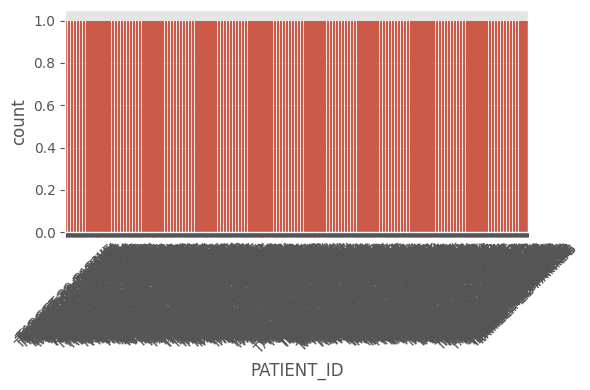

PROTOCOL


,count
PROTOCOL,
AAML0531,541
AAML03P1,52
CCG-2961,27


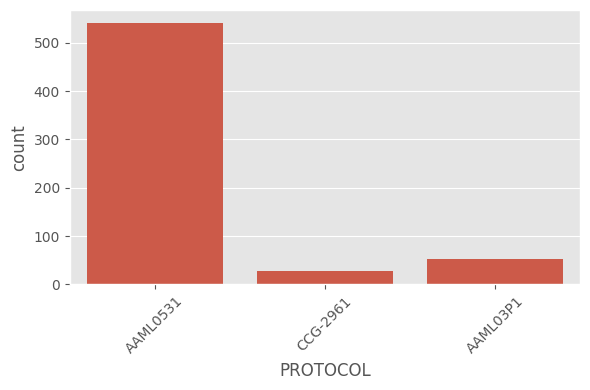

SEX


,count
SEX,
Male,310
Female,310


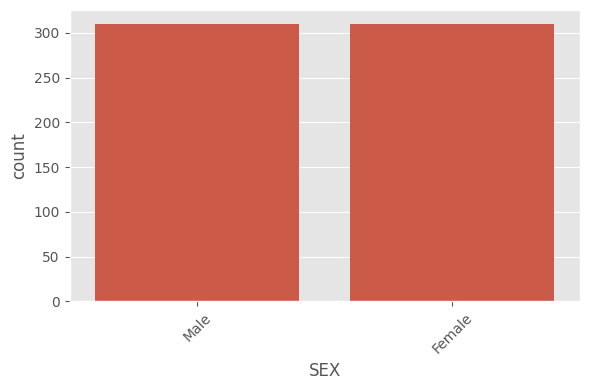

RACE


,count
RACE,
White,489
Black or African American,68
Asian,31
Other,27
American Indian or Alaska Native,3
Native Hawaiian or other Pacific Islander,2


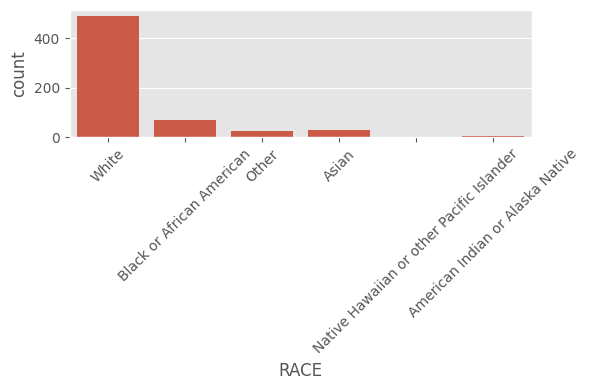

ETHNICITY


,count
ETHNICITY,
Not Hispanic or Latino,506
Hispanic or Latino,114


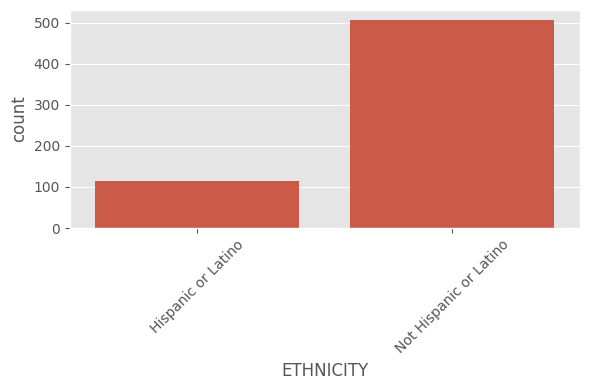

CNS_DISEASE


,count
CNS_DISEASE,
No,577
Yes,43


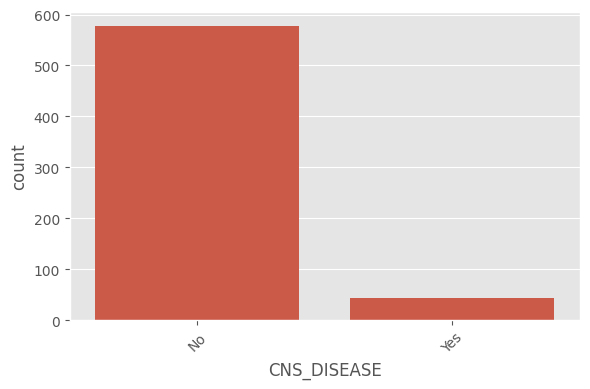

CHLOROMA


,count
CHLOROMA,
No,545
Yes,75


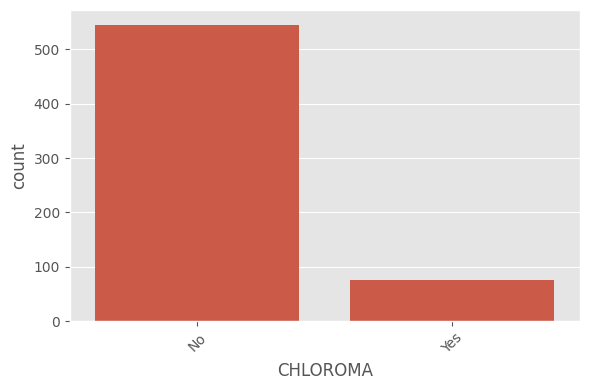

FAB


,count
FAB,
M2,210
M4,126
M5,118
M1,71
NOS,35
M7,27
M0,23
M6,10


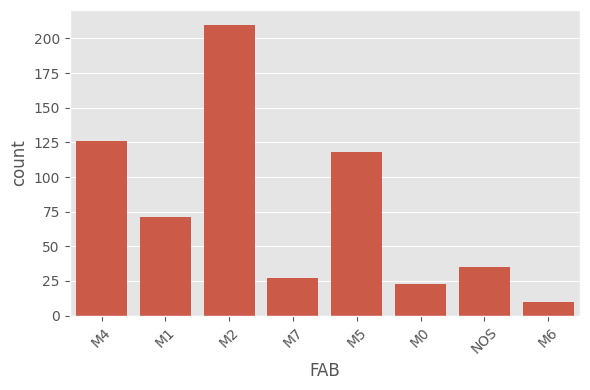

CYTOGENETIC_COMPLEXITY


,count
CYTOGENETIC_COMPLEXITY,
1,256
0,142
2,118
3,45
4,23
5,13
More than 6,11
6,9
10,2


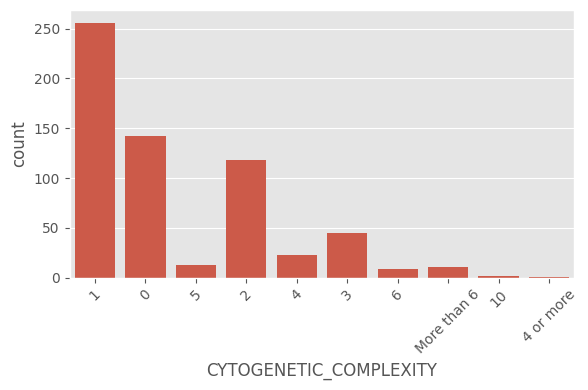

PRIMARY_CYTOGENETIC_CODE


,count
PRIMARY_CYTOGENETIC_CODE,
Other,199
Normal,137
MLL,123
t(8;21),87
inv(16),74


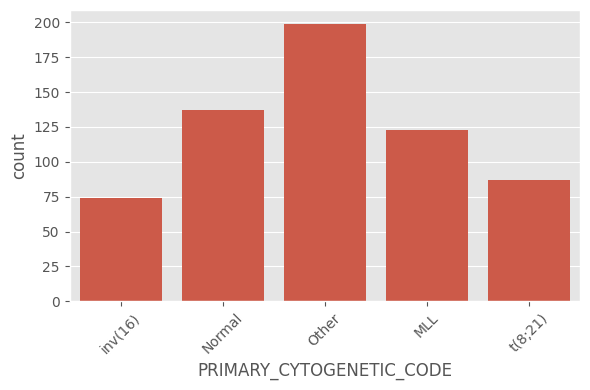

RISK_GROUP


,count
RISK_GROUP,
Standard,278
Low,238
High,79
10,1
30,1


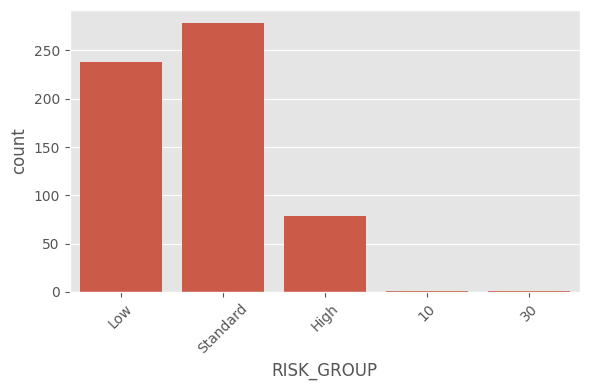

FIRST_EVENT


,count
FIRST_EVENT,
Censored,292
Relapse,225
Induction failure,59
Death,34
Death without remission,10


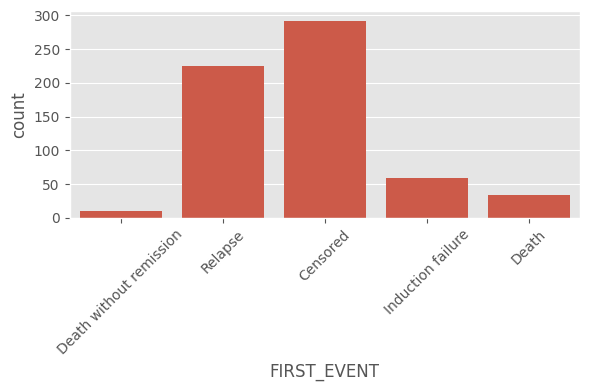

OS_STATUS


,count
OS_STATUS,
0:LIVING,397
1:DECEASED,223


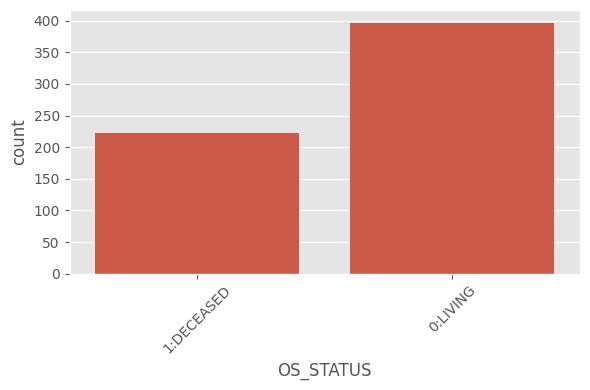

In [ ]:
for col in categorical_cols:

    print("="*40)
    print(col)
    print("="*40)

    display(df[col].value_counts())

    plt.figure(figsize=(6,4))

    sns.countplot(data=df,
                  x=col)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

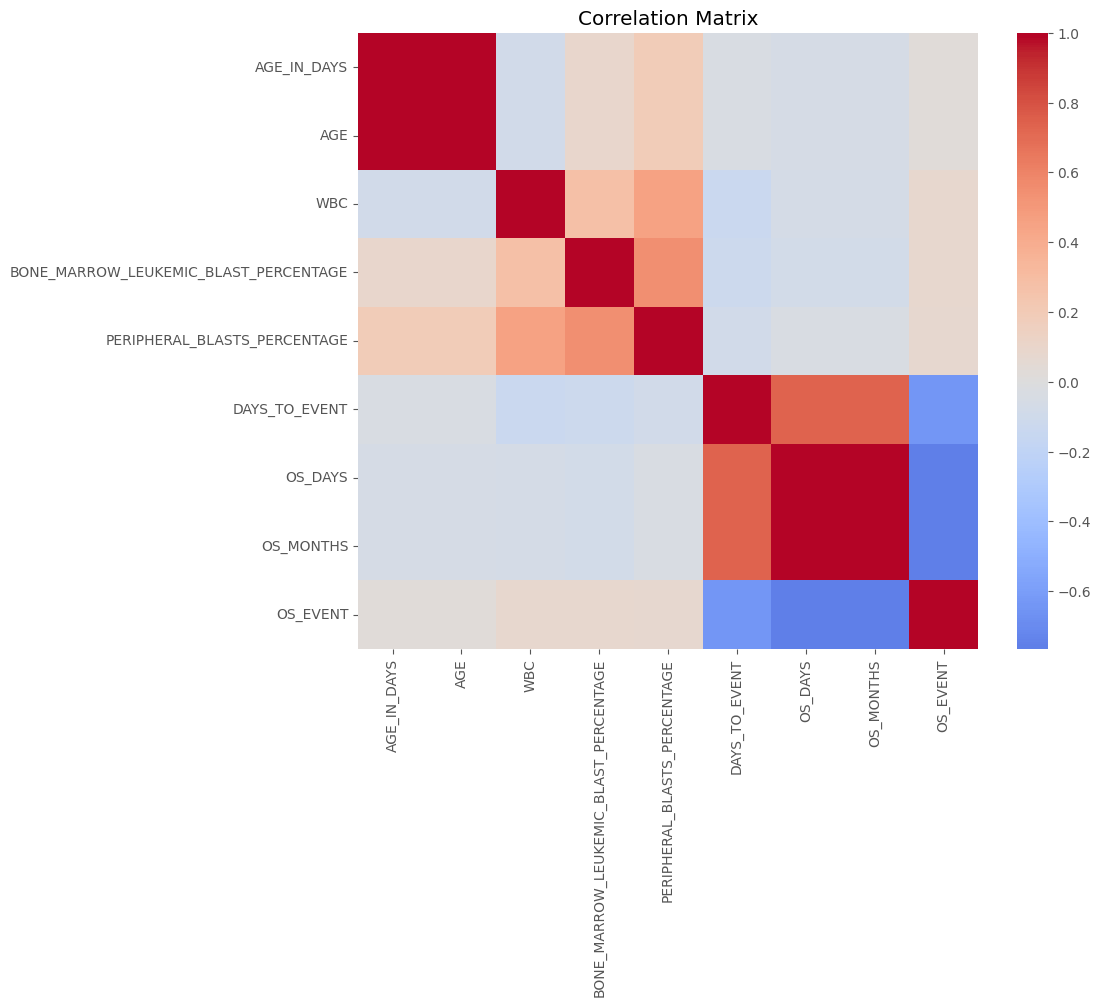

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

plt.title("Correlation Matrix")

plt.show()

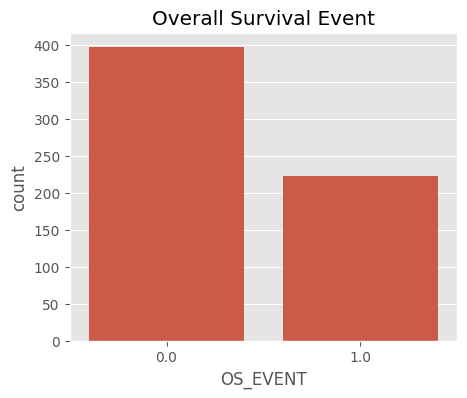

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(data=df,
              x="OS_EVENT")

plt.title("Overall Survival Event")

plt.show()

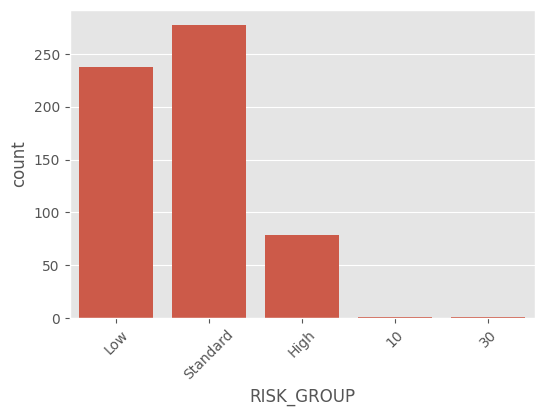

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="RISK_GROUP")

plt.xticks(rotation=45)

plt.show()

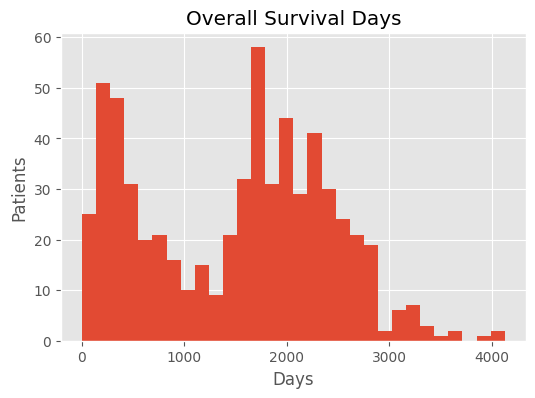

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df["OS_DAYS"],
         bins=30)

plt.title("Overall Survival Days")

plt.xlabel("Days")

plt.ylabel("Patients")

plt.show()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 7.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=307b83bfb2dc3c79a580d9763557107a8cc4398309c8e429337dc768d8452ed5
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


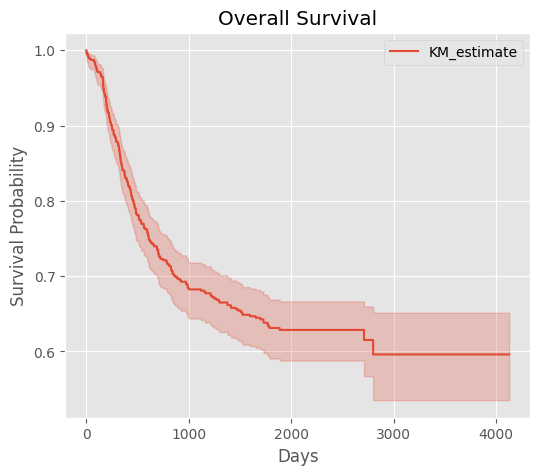

In [ ]:
!pip install lifelines
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

plt.figure(figsize=(6,5))

kmf.fit(
    durations=df["OS_DAYS"],
    event_observed=df["OS_EVENT"]
)

kmf.plot()

plt.title("Overall Survival")

plt.xlabel("Days")

plt.ylabel("Survival Probability")

plt.show()

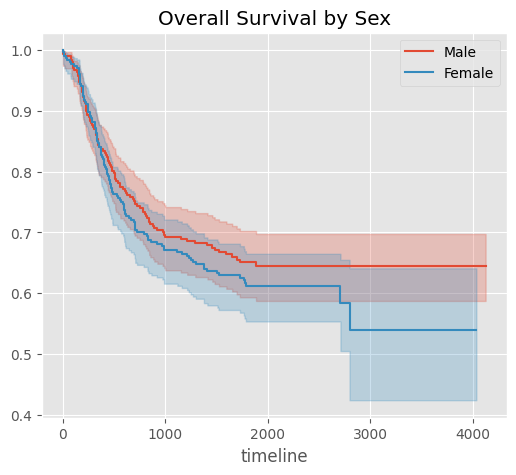

In [ ]:
plt.figure(figsize=(6,5))

for sex in df["SEX"].unique():

    subset = df[df["SEX"] == sex]

    kmf.fit(
        subset["OS_DAYS"],
        subset["OS_EVENT"],
        label=sex
    )

    kmf.plot()

plt.title("Overall Survival by Sex")

plt.show()

In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt
import pandas as pd


def plot_km_by_group(
    df,
    group_col,
    time_col="OS_DAYS",
    event_col="OS_EVENT",
    min_group_size=5
):
    """
    Plot Kaplan-Meier curves for each category in group_col.

    Parameters
    ----------
    df : pandas.DataFrame
        Training dataset.
    group_col : str
        Column used to divide patients into groups.
    time_col : str
        Survival-time column.
    event_col : str
        Event indicator: 1 = death, 0 = censored.
    min_group_size : int
        Groups with fewer patients are skipped.
    """

    required_cols = [group_col, time_col, event_col]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    plot_df = df[required_cols].copy()

    # Remove rows where group, time, or event information is unavailable.
    plot_df = plot_df.dropna(
        subset=[group_col, time_col, event_col]
    )

    # Convert group labels to strings for consistent plotting.
    plot_df[group_col] = plot_df[group_col].astype(str).str.strip()

    print(f"\nGroup counts for {group_col}:")
    print(plot_df[group_col].value_counts())

    kmf = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))

    included_groups = []

    for group_name, group_df in plot_df.groupby(group_col):
        if len(group_df) < min_group_size:
            print(
                f"Skipping {group_name}: only "
                f"{len(group_df)} patients"
            )
            continue

        kmf.fit(
            durations=group_df[time_col],
            event_observed=group_df[event_col],
            label=f"{group_name} (n={len(group_df)})"
        )

        kmf.plot_survival_function(
            ci_show=True
        )

        included_groups.append(group_name)

    plt.title(f"Overall Survival by {group_col}")
    plt.xlabel("Days")
    plt.ylabel("Survival Probability")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Statistical test comparing all included groups.
    tested_df = plot_df[
        plot_df[group_col].isin(included_groups)
    ]

    if len(included_groups) >= 2:
        result = multivariate_logrank_test(
            event_durations=tested_df[time_col],
            groups=tested_df[group_col],
            event_observed=tested_df[event_col]
        )

        print(
            f"Global log-rank p-value for {group_col}: "
            f"{result.p_value:.4g}"
        )
    else:
        print("Not enough valid groups for a log-rank test.")

In [ ]:
print(df["RISK_GROUP"].value_counts(dropna=False))

RISK_GROUP
Standard    278
Low         238
High         79
NaN          23
10            1
30            1
Name: count, dtype: int64


In [ ]:
risk_mapping = {
    "Low": "Low",
    "Standard": "Standard",
    "High": "High",
    "10": "Low",
    "30": "High"
}

df["RISK_GROUP_CLEAN"] = (
    df["RISK_GROUP"]
    .astype(str)
    .str.strip()
    .map(risk_mapping)
)


Group counts for RISK_GROUP_CLEAN:
RISK_GROUP_CLEAN
Standard    278
Low         239
High         80
Name: count, dtype: int64


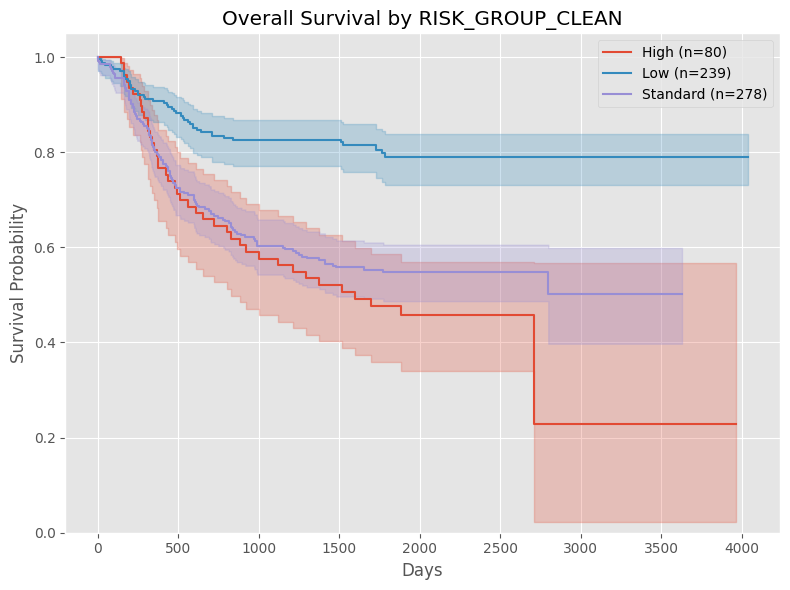

Global log-rank p-value for RISK_GROUP_CLEAN: 8.456e-10


In [ ]:
plot_km_by_group(
    df,
    group_col="RISK_GROUP_CLEAN"
)